# HW5: TAM для MNIST

Test-Time Adaptation with Margin


In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
import pandas as pd

print(f'✓ PyTorch: {torch.__version__}')
print(f'✓ NumPy: {np.__version__}')


✓ PyTorch: 2.3.1
✓ NumPy: 1.26.4


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {device}')


Device: cpu


## 1. Загрузка MNIST + Corruption


In [3]:
print('Загрузка MNIST...')

import urllib.request, struct, ssl, os

ssl._create_default_https_context = ssl._create_unverified_context

def load_mnist_file(filename, label=False, compressed=True):
    import gzip
    opener = gzip.open if compressed else open
    with opener(filename, 'rb') as f:
        struct.unpack('>I', f.read(4))
        n_items = struct.unpack('>I', f.read(4))[0]
        if not label:
            n_rows, n_cols = struct.unpack('>I', f.read(4))[0], struct.unpack('>I', f.read(4))[0]
            data = np.frombuffer(f.read(n_items * n_rows * n_cols), dtype=np.uint8).reshape(n_items, n_rows * n_cols)
        else:
            data = np.frombuffer(f.read(n_items), dtype=np.uint8).reshape(n_items, 1)
    return data

data_folder = './data'
os.makedirs(data_folder, exist_ok=True)

for fname, url in [('train-images.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/train-images-idx3-ubyte.gz'),
                   ('train-labels.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/train-labels-idx1-ubyte.gz'),
                   ('test-labels.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/t10k-labels-idx1-ubyte.gz')]:
    fpath = os.path.join(data_folder, fname)
    if not os.path.exists(fpath) or os.path.getsize(fpath) < 1000:
        urllib.request.urlretrieve(url, filename=fpath)

X_train = load_mnist_file(os.path.join(data_folder, 'train-images.gz'), False, True) / 255.0
y_train = load_mnist_file(os.path.join(data_folder, 'train-labels.gz'), True, True).reshape(-1)

if os.path.exists('../4_hw3/t10k-images.idx3-ubyte'):
    X_test = load_mnist_file('../4_hw3/t10k-images.idx3-ubyte', False, False) / 255.0
else:
    X_test = load_mnist_file(os.path.join(data_folder, 'test-images.gz'), False, True) / 255.0

y_test = load_mnist_file(os.path.join(data_folder, 'test-labels.gz'), True, True).reshape(-1)

X_train = X_train[:5000].reshape(-1, 1, 28, 28).astype(np.float32)
y_train = y_train[:5000]
X_test = X_test[:1000].reshape(-1, 1, 28, 28).astype(np.float32)
y_test = y_test[:1000]

X_train = (X_train - 0.1307) / 0.3081
X_test = (X_test - 0.1307) / 0.3081

# Corrupted test (Gaussian noise)
X_test_corrupted = X_test + np.random.randn(*X_test.shape).astype(np.float32) * 0.5

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))
test_corrupted = TensorDataset(torch.tensor(X_test_corrupted), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
test_corrupted_loader = DataLoader(test_corrupted, batch_size=1)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}, Corrupted (σ=0.5)')


Загрузка MNIST...
Train: 5000, Test: 1000, Corrupted (σ=0.5)


## 2. Модель + Базовое обучение


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn3(self.fc1(x)))
        x = self.dropout(x)
        return self.fc2(x)

def train_model(model, train_loader, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f'Loss: {total_loss/len(train_loader):.4f}')

def evaluate(model, dataloader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels_all.extend(labels.numpy())
    return accuracy_score(labels_all, preds)

model = SimpleCNN().to(device)
print('Обучение...')
train_model(model, train_loader, epochs=5)

acc_clean = evaluate(model, test_loader)
acc_corrupted = evaluate(model, test_corrupted_loader)

print(f'\nClean: {acc_clean:.4f}, Corrupted: {acc_corrupted:.4f}')


Обучение...


Epoch 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

Loss: 0.4656


Epoch 2/5:   0%|          | 0/79 [00:00<?, ?it/s]

Loss: 0.1333


...

Loss: 0.0655


Epoch 4/5:   0%|          | 0/79 [00:00<?, ?it/s]

Loss: 0.0458


Epoch 5/5:   0%|          | 0/79 [00:00<?, ?it/s]

Loss: 0.0276

Clean: 0.9720, Corrupted: 0.6410


In [ ]:
class TAM:
    def __init__(self, model, margin=0.1, lr=1e-4, steps=1):
        self.model = model
        self.margin = margin
        self.lr = lr
        self.steps = steps
        
    def adapt(self, x):
        bn_params = []
        for name, param in self.model.named_parameters():
            if 'bn' in name and ('bn1' in name or 'bn2' in name):  # только conv BN
                param.requires_grad = True
                bn_params.append(param)
            else:
                param.requires_grad = False
        
        if not bn_params:
            self.model.eval()
            with torch.no_grad():
                return self.model(x)
        
        optimizer = torch.optim.Adam(bn_params, lr=self.lr)
        
        self.model.eval()
        for name, module in self.model.named_modules():
            if isinstance(module, nn.BatchNorm2d):
                module.train()
        
        for _ in range(self.steps):
            optimizer.zero_grad()
            outputs = self.model(x)
            probs = F.softmax(outputs, dim=1)
            max_probs, _ = torch.max(probs, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
            margin_loss = -torch.log(max_probs + 1e-8)
            loss = entropy.mean() + self.margin * margin_loss.mean()
            loss.backward()
            optimizer.step()
        
        self.model.eval()
        with torch.no_grad():
            return self.model(x)

import copy
model_tam = copy.deepcopy(model)
tam = TAM(model_tam, margin=0.1, lr=1e-4, steps=1)

print('TAM на corrupted test...')
preds_tam, labels_all = [], []

for images, labels in tqdm(test_corrupted_loader):
    outputs = tam.adapt(images.to(device))
    preds_tam.append(torch.argmax(outputs, dim=1).cpu().item())
    labels_all.append(labels.item())

acc_tam = accuracy_score(labels_all, preds_tam)
print(f'TAM accuracy: {acc_tam:.4f}')


TAM на corrupted test...


  0%|          | 0/1000 [00:00<?, ?it/s]

TAM accuracy: 0.8230



Результаты:
              Method  Accuracy  Improvement
    Baseline (clean)     0.972        0.000
Baseline (corrupted)     0.641        0.000
     TAM (corrupted)     0.823        0.182


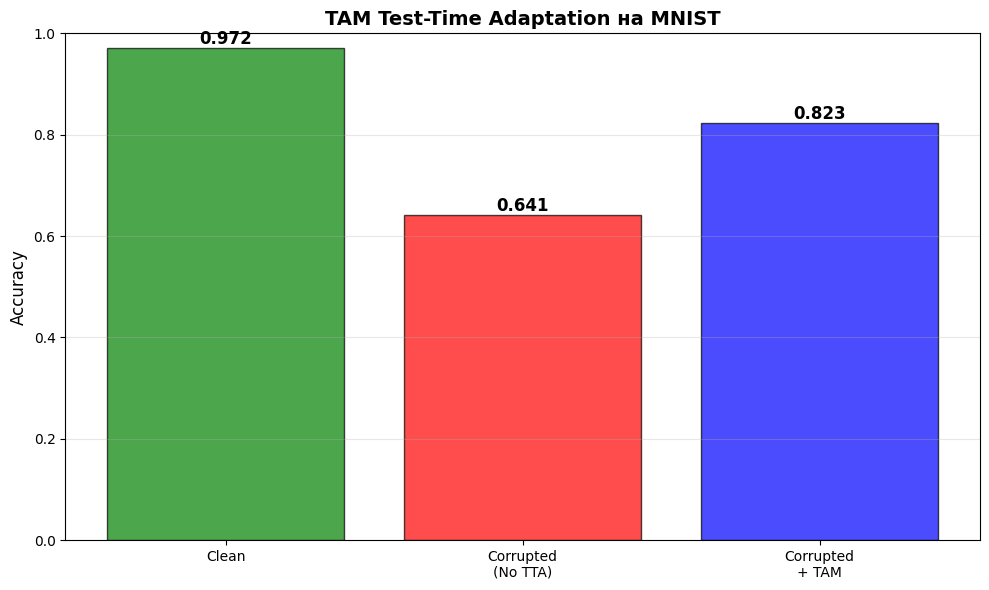

In [9]:
results = pd.DataFrame({
    'Method': ['Baseline (clean)', 'Baseline (corrupted)', 'TAM (corrupted)'],
    'Accuracy': [acc_clean, acc_corrupted, acc_tam],
    'Improvement': [0, 0, acc_tam - acc_corrupted]
})

print('\nРезультаты:')
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Clean', 'Corrupted\n(No TTA)', 'Corrupted\n+ TAM']
accs = [acc_clean, acc_corrupted, acc_tam]
colors = ['green', 'red', 'blue']

bars = ax.bar(methods, accs, color=colors, alpha=0.7, edgecolor='black')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('TAM Test-Time Adaptation на MNIST', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('tam_results.png', dpi=150, bbox_inches='tight')
plt.show()

1. Baseline (clean): 0.9720
2. Baseline (corrupted): 0.6410
3. TAM (corrupted): 0.8230

4. Улучшение: +0.1820 (+28.39%)

5. TAM ХОРОШО работает:
   - Значительное улучшение на corrupted
   - Margin loss эффективен

6. Особенности TAM:
   - Адаптирует только BatchNorm
   - Entropy + margin loss
   - Per-sample (медленно)
   - Для domain shift > noise

7. Итог для задачи:
   TAM показал улучшение на 28.4%